# Backtesting the expected-minutes model on the 2025/26 season

Compares the new competitor-absence-aware `MinutesModel` (`airsenal.framework.minutes_model`) against
the old baseline it replaced: `own_recent_minutes`, the mean of a player's own last 3 matches' minutes,
which is what the previous prediction code implicitly used as its estimate of expected minutes (see git
history of `prediction_utils.calc_predicted_points_for_player`).

We hold out the completed 2025/26 season (`season == "2526"`) entirely and refit the model on every other
past season, so this is a genuine out-of-season backtest rather than training-set performance. 2025/26 is
used as the test season (rather than the current, in-progress season) because it's fully finished and so
has reliable per-gameweek `Absence` records - the in-progress season only has *live*, as-of-today
availability status, which wouldn't reflect what was actually known at each past gameweek.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from airsenal.framework.minutes_model import MinutesModel, build_minutes_feature_frame
from airsenal.framework.schema import session

## Build the feature frame

One query across all seasons we have `PlayerScore` data for; we split it by season below. This is the
same feature engineering used in production (`fit_minutes_model`/`build_minutes_training_data`), just kept
at full (player_id, season, gameweek) granularity here so we can hold out a specific season ourselves.

In [2]:
feature_frame = build_minutes_feature_frame(dbsession=session)
feature_frame["season"].value_counts().sort_index()

Filling history dataframe for Raya: 0/1534 done
Filling history dataframe for Arrizabalaga: 1/1534 done
Filling history dataframe for Meslier: 2/1534 done
Filling history dataframe for Gabriel: 3/1534 done
Filling history dataframe for J.Timber: 4/1534 done
Filling history dataframe for Saliba: 5/1534 done
Filling history dataframe for Lewis-Skelly: 6/1534 done
Filling history dataframe for Calafiori: 7/1534 done
Filling history dataframe for Hincapie: 8/1534 done
Filling history dataframe for White: 9/1534 done
Filling history dataframe for Mosquera: 10/1534 done
Filling history dataframe for Saka: 11/1534 done
Filling history dataframe for Rice: 12/1534 done
Filling history dataframe for Eze: 13/1534 done
Filling history dataframe for Ødegaard: 14/1534 done
Filling history dataframe for Madueke: 15/1534 done
Filling history dataframe for Merino: 16/1534 done
Filling history dataframe for Martinelli: 17/1534 done
Filling history dataframe for Zubimendi: 18/1534 done
Filling history da

season
2324    28300
2425    26325
2526    28444
Name: count, dtype: int64

## Train/test split

Hold out 2025/26 completely - train the model on every other season only.

In [3]:
TEST_SEASON = "2526"

train_df = feature_frame[feature_frame["season"] != TEST_SEASON]
test_df = feature_frame[feature_frame["season"] == TEST_SEASON].copy()

print(f"train rows: {len(train_df)}, test rows: {len(test_df)}")
train_df["season"].value_counts().sort_index()

train rows: 54625, test rows: 28444


season
2324    28300
2425    26325
Name: count, dtype: int64

## Fit the new model and compare against the baseline

Baseline = `own_recent_minutes` (mean of the player's own last 3 matches) - directly comparable to the new
model's prediction since both are estimates of the same target: `minutes` in the held-out fixture.

In [4]:
model = MinutesModel().fit(train_df)

test_df["baseline_pred"] = test_df["own_recent_minutes"]
test_df["model_pred"] = model.predict(test_df)
test_df["baseline_error"] = (test_df["baseline_pred"] - test_df["minutes"]).abs()
test_df["model_error"] = (test_df["model_pred"] - test_df["minutes"]).abs()

test_df[
    [
        "own_recent_minutes",
        "n_teammates_absent",
        "position",
        "minutes",
        "baseline_pred",
        "model_pred",
    ]
].head()

,own_recent_minutes,n_teammates_absent,position,minutes,baseline_pred,model_pred
76,90.0,0,GK,90,90.0,82.918849
77,90.0,0,GK,90,90.0,82.918849
78,90.0,0,GK,90,90.0,82.918849
79,90.0,0,GK,90,90.0,82.918849
80,90.0,0,GK,90,90.0,82.918849


## Overall error metrics

In [5]:
def summarise(df, label):
    mae_baseline = df["baseline_error"].mean()
    mae_model = df["model_error"].mean()
    rmse_baseline = np.sqrt((df["baseline_pred"] - df["minutes"]).pow(2).mean())
    rmse_model = np.sqrt((df["model_pred"] - df["minutes"]).pow(2).mean())
    print(f"{label} (n={len(df)})")
    print(f"  MAE  baseline={mae_baseline:.2f}  model={mae_model:.2f}")
    print(f"  RMSE baseline={rmse_baseline:.2f}  model={rmse_model:.2f}")


summarise(test_df, "All rows")

All rows (n=28444)
  MAE  baseline=11.73  model=14.13
  RMSE baseline=24.00  model=23.16


## Where the new model should help most: rows with an absent competitor

The baseline ignores teammate availability entirely, so this is the subset where we'd expect the new
model to pull ahead - and the split where the old zero-heavy-history bug (see the module docstring in
`minutes_model.py`) used to bite hardest.

In [6]:
has_absent_competitor = test_df["n_teammates_absent"] > 0

summarise(test_df[has_absent_competitor], "Rows with >=1 absent same-position teammate")
summarise(test_df[~has_absent_competitor], "Rows with no absent teammates")

pct = has_absent_competitor.mean()
print(f"\n{pct:.1%} of rows have at least one absent same-position teammate")

Rows with >=1 absent same-position teammate (n=10866)
  MAE  baseline=12.43  model=14.66
  RMSE baseline=24.33  model=23.32
Rows with no absent teammates (n=17578)
  MAE  baseline=11.30  model=13.80
  RMSE baseline=23.79  model=23.06

38.2% of rows have at least one absent same-position teammate


## Plots

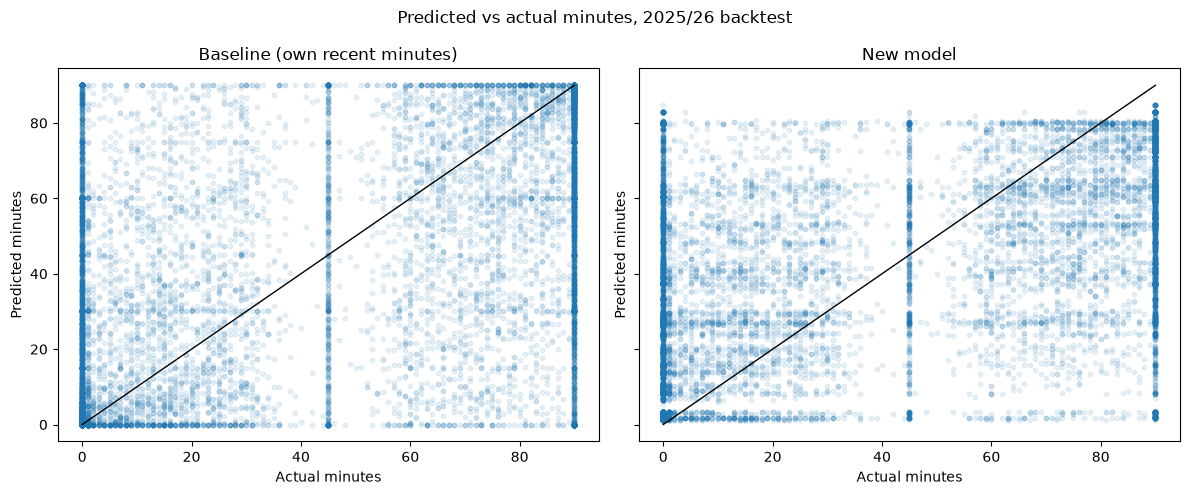

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)
for ax, col, title in zip(
    axes,
    ["baseline_pred", "model_pred"],
    ["Baseline (own recent minutes)", "New model"],
    strict=True,
):
    ax.scatter(test_df["minutes"], test_df[col], alpha=0.1, s=10)
    ax.plot([0, 90], [0, 90], color="black", linewidth=1)
    ax.set_xlabel("Actual minutes")
    ax.set_ylabel("Predicted minutes")
    ax.set_title(title)
fig.suptitle("Predicted vs actual minutes, 2025/26 backtest")
fig.tight_layout()

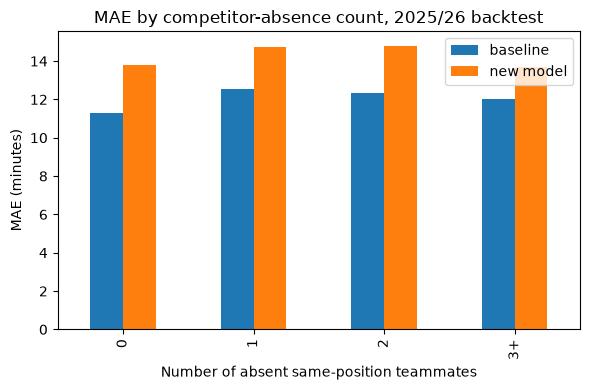

In [8]:
bucket = test_df["n_teammates_absent"].clip(upper=3)
mae_by_bucket = (
    test_df.assign(bucket=bucket)
    .groupby("bucket")[["baseline_error", "model_error"]]
    .mean()
)
mae_by_bucket.index = [str(i) if i < 3 else "3+" for i in mae_by_bucket.index]
mae_by_bucket = mae_by_bucket.rename(
    columns={"baseline_error": "baseline", "model_error": "new model"}
)

mae_by_bucket.plot(kind="bar", figsize=(6, 4))
plt.ylabel("MAE (minutes)")
plt.xlabel("Number of absent same-position teammates")
plt.title("MAE by competitor-absence count, 2025/26 backtest")
plt.tight_layout()

## Caveats

- This only evaluates *minutes* accuracy, not downstream points accuracy. The points-scoring formulas
  (e.g. `get_appearance_points`) are non-linear step functions of minutes, so a single expected-minutes
  number run through them once isn't exactly the same as averaging points over a distribution of possible
  minutes outcomes - `E[points(minutes)] != points(E[minutes])`. That trade-off was made deliberately (a
  single drop-in number was the explicit goal), but it means this notebook doesn't tell us how that
  approximation affects final predicted points, only whether the minutes number itself is better.
- FPL positions are coarse (e.g. left-back and centre-back aren't distinguished), so "same position" here
  is an approximation of "direct competitor for the same starting slot", not a real depth chart.
- The historical `Absence` data (used for `n_teammates_absent` in past seasons) is TransferMarkt-derived
  and known to have some gaps/errors - see `notebooks/minutes_estimation_data.ipynb` for examples found
  during data cleaning.